# FIT5196 Assessment 2 Task 2：从零开始的中文教学 Notebook


根据 assignment guide，Task 2 不是要训练一个最终预测模型，而是要研究 **data reshaping**：

- 数据文件只使用 `suburb_info.xlsx`。
- 目标变量是 `median_house_price`。
- 需要研究的特征是：
  - `number_of_houses`
  - `number_of_units`
  - `population`
  - `aus_born_perc`
  - `median_income`
- 需要比较 normalisation / transformation 方法，例如 standardisation、min-max、log、power、Box-Cox。
- 判断依据主要有两个：
  - 特征是否在合适、可比较的 scale 上。
  - 特征和目标变量是否更接近线性关系。

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

ROOT = Path.cwd()
DATA_FILE = ROOT / "suburb_info.xlsx"

print("Working directory:", ROOT)
print("Data file exists:", DATA_FILE.exists())

Working directory: /Users/songhaifan/Documents/GitHub/teaching-materials/courses/lincoin/materials/fit5196/ass2_2026
Data file exists: True


In [2]:
suburb_data = pd.read_excel(DATA_FILE)

print("Dataset shape:", suburb_data.shape)
print("Column names:")
for column in suburb_data.columns:
    print("-", column)

print()
print("First five rows:")
display(suburb_data.head())

column_overview = pd.DataFrame({
    "dtype": suburb_data.dtypes.astype(str),
    "missing_count": suburb_data.isna().sum(),
    "missing_percent": suburb_data.isna().mean() * 100,
    "unique_count": suburb_data.nunique(dropna=True),
})

print("Column overview:")
display(column_overview)

Dataset shape: (202, 8)
Column names:
- suburb
- number_of_houses
- number_of_units
- municipality
- aus_born_perc
- median_income
- median_house_price
- population

First five rows:


,suburb,number_of_houses,number_of_units,municipality,aus_born_perc,median_income,median_house_price,population
0,ABBOTSFORD,2304,4706,Yarra,68%,"$1,797","$1,299,400",4025
1,ABERFELDIE,1410,453,Moonee Valley,81%,"$1,571","$1,926,600",22442
2,ALBANVALE,1897,138,Brimbank,46%,$907,"$594,200",54005
3,ALBION,1389,1392,Brimbank,52%,$929,"$739,100",30677
4,ALPHINGTON,1729,1099,Darebin,73%,"$1,538","$1,729,600",9227


Column overview:


,dtype,missing_count,missing_percent,unique_count
suburb,str,0,0.0000,202
number_of_houses,int64,0,0.0000,198
number_of_units,int64,0,0.0000,197
municipality,str,0,0.0000,28
aus_born_perc,str,0,0.0000,40
median_income,str,0,0.0000,129
median_house_price,str,0,0.0000,201
population,int64,0,0.0000,135


In [3]:
suburb_data.dtypes

suburb                  str
number_of_houses      int64
number_of_units       int64
municipality            str
aus_born_perc           str
median_income           str
median_house_price      str
population            int64
dtype: object

## 把字符串字段转换成数值字段

从上一步 output 可以看到，`aus_born_perc`、`median_income`、`median_house_price` 虽然表达的是数值，但目前是字符串：

- `aus_born_perc` 带有 `%`
- `median_income` 和 `median_house_price` 带有 `$` 和逗号

这一步我们只做格式转换，不改变变量含义：

- `68%` 转成 `68.0`
- `$1,797` 转成 `1797.0`
- `$1,299,400` 转成 `1299400.0`

In [4]:
analysis_data = suburb_data.copy()

analysis_data["aus_born_perc"] = (
    analysis_data["aus_born_perc"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .astype(float)
)


In [5]:
analysis_data.dtypes

suburb                    str
number_of_houses        int64
number_of_units         int64
municipality              str
aus_born_perc         float64
median_income             str
median_house_price        str
population              int64
dtype: object

In [6]:
analysis_data["aus_born_perc"].sample(5)

106   65.0000
108   58.0000
17    79.0000
99    70.0000
188   71.0000
Name: aus_born_perc, dtype: float64

In [7]:
for money_column in ["median_income", "median_house_price"]:
    analysis_data[money_column] = (
        analysis_data[money_column]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float)
    )
analysis_data[["median_income", "median_house_price"]].sample(5)

,median_income,median_house_price
110,"1,541.0000","1,047,100.0000"
19,"1,538.0000","1,649,200.0000"
123,"1,284.0000","908,900.0000"
145,"1,538.0000","1,746,300.0000"
53,"1,116.0000","927,200.0000"


In [8]:
analysis_data.dtypes

suburb                    str
number_of_houses        int64
number_of_units         int64
municipality              str
aus_born_perc         float64
median_income         float64
median_house_price    float64
population              int64
dtype: object

In [9]:

selected_columns = [
    "number_of_houses",
    "number_of_units",
    "population",
    "aus_born_perc",
    "median_income",
    "median_house_price",
]

print("Converted dtypes:")
print(analysis_data[selected_columns].dtypes)

print()
print("First five converted rows:")
display(analysis_data[selected_columns].head())

print()
print("Missing values after conversion:")
print(analysis_data[selected_columns].isna().sum())

Converted dtypes:
number_of_houses        int64
number_of_units         int64
population              int64
aus_born_perc         float64
median_income         float64
median_house_price    float64
dtype: object

First five converted rows:


,number_of_houses,number_of_units,population,aus_born_perc,median_income,median_house_price
0,2304,4706,4025,68.0000,"1,797.0000","1,299,400.0000"
1,1410,453,22442,81.0000,"1,571.0000","1,926,600.0000"
2,1897,138,54005,46.0000,907.0000,"594,200.0000"
3,1389,1392,30677,52.0000,929.0000,"739,100.0000"
4,1729,1099,9227,73.0000,"1,538.0000","1,729,600.0000"



Missing values after conversion:
number_of_houses      0
number_of_units       0
population            0
aus_born_perc         0
median_income         0
median_house_price    0
dtype: int64


In [10]:
summary = analysis_data[selected_columns].describe().T
print("Summary statistics:")
display(summary)

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
number_of_houses,202.0000,"4,155.7673","3,400.8650",283.0000,"1,973.5000","3,256.5000","5,518.5000","23,338.0000"
number_of_units,202.0000,"2,480.4109","3,132.6847",60.0000,620.5000,"1,603.0000","3,089.0000","24,380.0000"
population,202.0000,"18,659.3119","9,604.1873",170.0000,"12,063.0000","17,583.0000","24,045.0000","54,005.0000"
aus_born_perc,202.0000,68.3663,10.7613,36.0000,62.0000,70.0000,77.0000,88.0000
median_income,202.0000,"1,387.9356",317.8413,633.0000,"1,182.2500","1,393.0000","1,560.0000","2,352.0000"
median_house_price,202.0000,"1,218,816.8317","471,680.7351","507,200.0000","870,675.0000","1,134,500.0000","1,467,550.0000","2,875,800.0000"


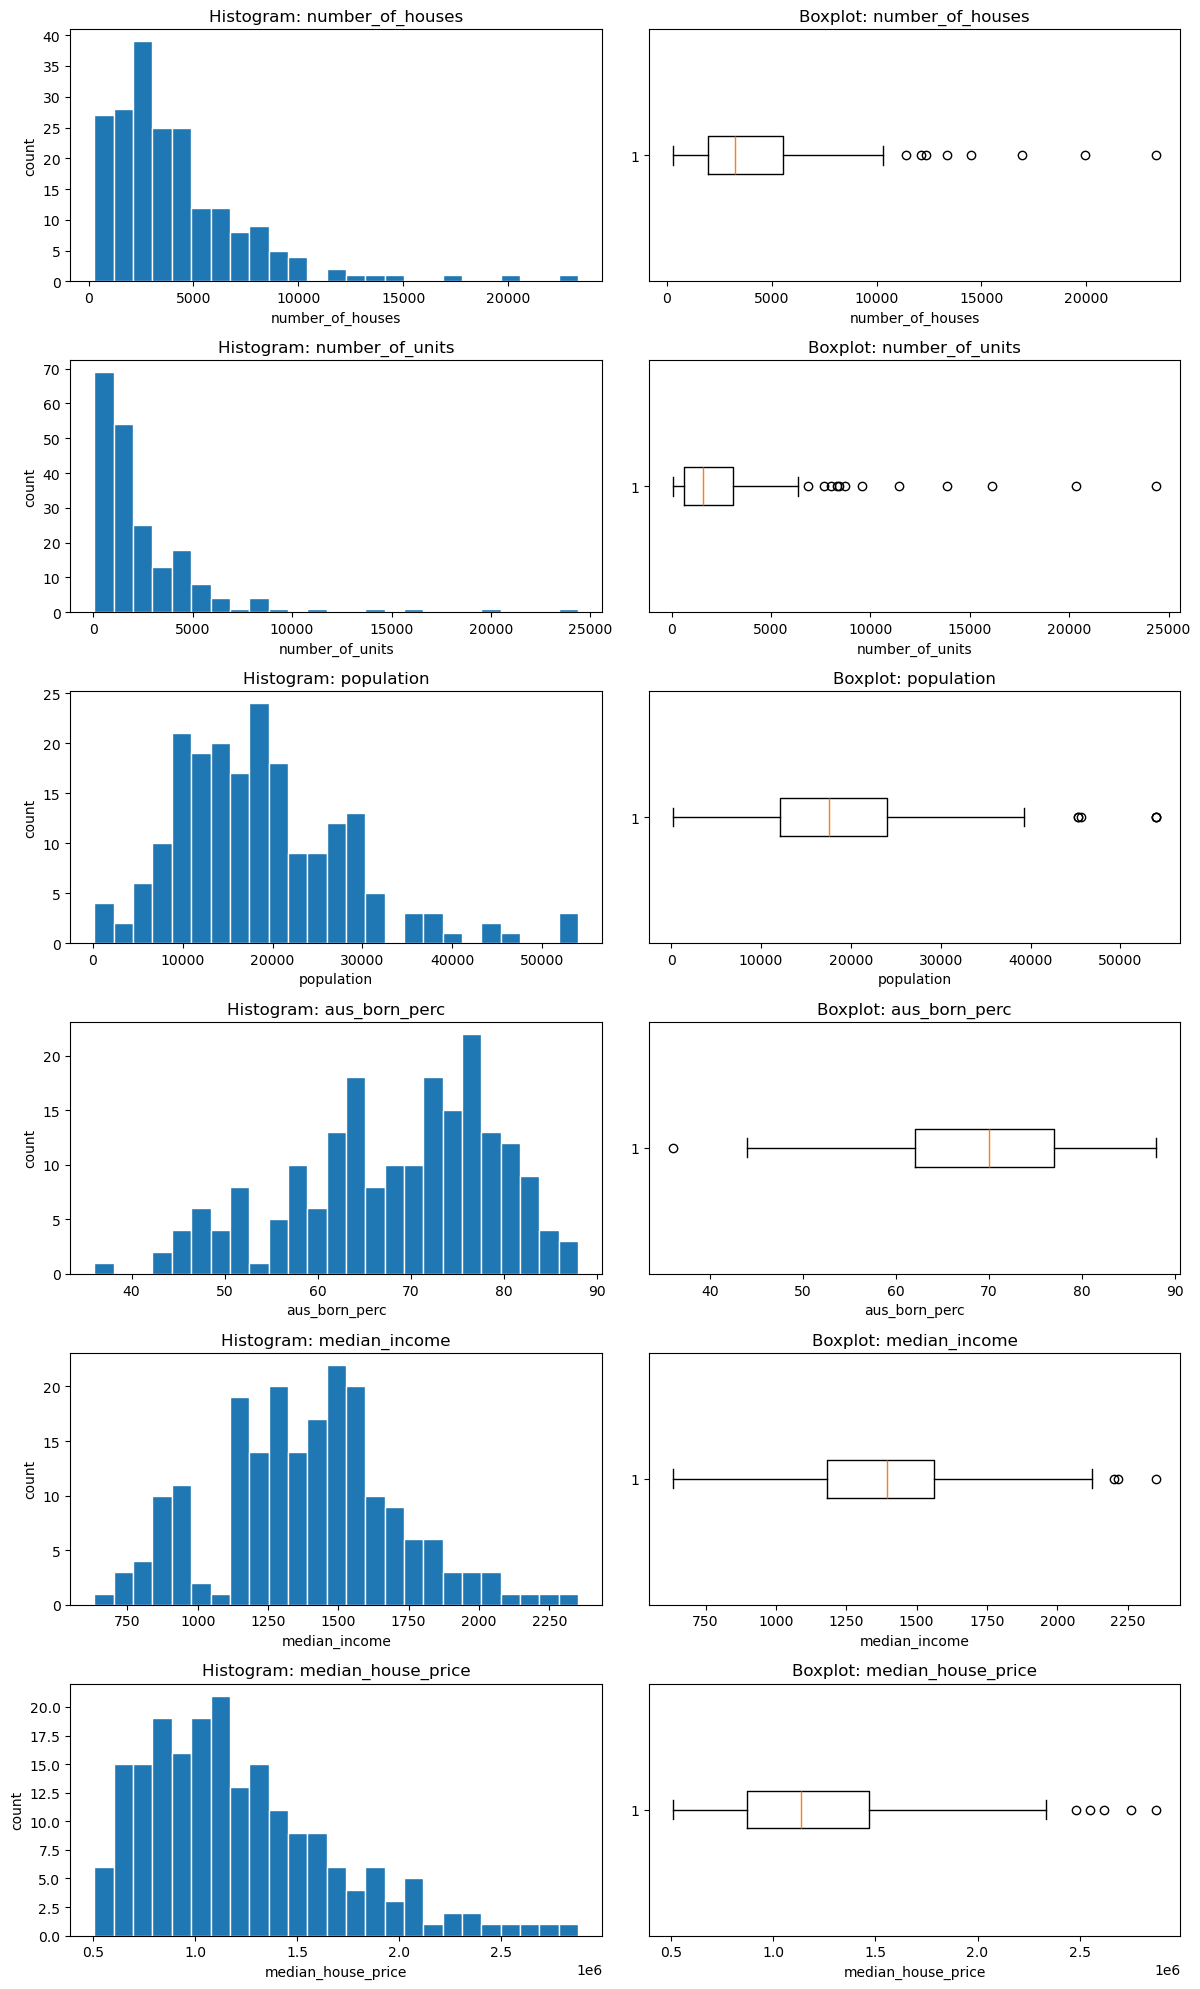


Top 5 values for number_of_houses:


,suburb,number_of_houses
0,POINT COOK,23338
1,CRAIGIEBURN,19933
2,RESERVOIR,16913
3,WERRIBEE,14482
4,EPPING,13368



Top 5 values for number_of_units:


,suburb,number_of_units
0,SOUTHBANK,24380
1,SOUTH YARRA,20356
2,CARLTON,16139
3,RICHMOND,13869
4,HAWTHORN,11459



Top 5 values for population:


...

,suburb,aus_born_perc
0,DIAMOND CREEK,88.0000
1,MONTMORENCY,87.0000
2,WILLIAMS LANDING,87.0000
3,ELTHAM,85.0000
4,ELTHAM NORTH,85.0000



Top 5 values for median_income:


,suburb,median_income
0,CANTERBURY,"2,352.0000"
1,PLENTY,"2,215.0000"
2,BRIGHTON,"2,200.0000"
3,CAMBERWELL,"2,122.0000"
4,KOOYONG,"2,047.0000"



Top 5 values for median_house_price:


,suburb,median_house_price
0,CANTERBURY,"2,875,800.0000"
1,TOORAK,"2,752,300.0000"
2,SOUTHBANK,"2,621,500.0000"
3,BALWYN,"2,551,100.0000"
4,BRIGHTON,"2,483,600.0000"


In [11]:
figure_dir = ROOT / "task2_figures"
figure_dir.mkdir(exist_ok=True)

distribution_figure_path = figure_dir / "task2_raw_distributions.png"

fig, axes = plt.subplots(len(selected_columns), 2, figsize=(12, 20))

for row_index, column in enumerate(selected_columns):
    axes[row_index, 0].hist(analysis_data[column], bins=25, edgecolor="white")
    axes[row_index, 0].set_title(f"Histogram: {column}")
    axes[row_index, 0].set_xlabel(column)
    axes[row_index, 0].set_ylabel("count")

    axes[row_index, 1].boxplot(analysis_data[column], vert=False)
    axes[row_index, 1].set_title(f"Boxplot: {column}")
    axes[row_index, 1].set_xlabel(column)

plt.tight_layout()
fig.savefig(distribution_figure_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)

for column in selected_columns:
    print()
    print(f"Top 5 values for {column}:")
    display(
        analysis_data[["suburb", column]]
        .sort_values(column, ascending=False)
        .head(5)
        .reset_index(drop=True)
    )

看图和 top values 后，我们重点讨论：

1. 哪些变量的 histogram 明显右偏？这是否支持 log / power transformation？
2. 哪些变量只是 scale 大，但分布形状还可以？这类变量可能只需要 standardisation 或 min-max。
3. `aus_born_perc` 的分布和其他变量不同，它是否应该避免 log transformation？
4. 对 Task 2 来说，我们是否应该把“outlier removal”作为主要方案？还是更应该讨论 transformation？

原始特征和目标变量的线性关系 baseline

Assignment guide 的第二个判断标准是：变换之后，features 应该和 target 有尽可能强的线性关系。

所以在尝试任何 transformation 之前，我们需要建立 baseline：

- 横轴：每个 feature
- 纵轴：`median_house_price`
- 图形：scatter plot，用肉眼看是否接近线性趋势
- 数字：Pearson correlation，用一个数值衡量线性关系强弱

注意：Pearson correlation 只衡量线性关系。如果图里是弯曲趋势，相关系数可能低估变量和目标之间的关系，这正是 transformation 可能有用的地方。

In [12]:
target_column = "median_house_price"
feature_columns = [
    "number_of_houses",
    "number_of_units",
    "population",
    "aus_born_perc",
    "median_income",
]

correlation_rows = []
for feature in feature_columns:
    pearson_corr = analysis_data[feature].corr(analysis_data[target_column], method="pearson")
    spearman_corr = analysis_data[feature].corr(analysis_data[target_column], method="spearman")
    correlation_rows.append({
        "feature": feature,
        "pearson_correlation": pearson_corr,
        "spearman_correlation": spearman_corr,
        "absolute_pearson": abs(pearson_corr),
    })

baseline_correlation = (
    pd.DataFrame(correlation_rows)
    .sort_values("absolute_pearson", ascending=False)
    .reset_index(drop=True)
)

print("Baseline correlations with median_house_price:")
display(baseline_correlation)


Baseline correlations with median_house_price:


,feature,pearson_correlation,spearman_correlation,absolute_pearson
0,median_income,0.7194,0.6969,0.7194
1,number_of_units,0.3439,0.3095,0.3439
2,aus_born_perc,0.3039,0.2950,0.3039
3,population,-0.2872,-0.2430,0.2872
4,number_of_houses,-0.1045,-0.0576,0.1045


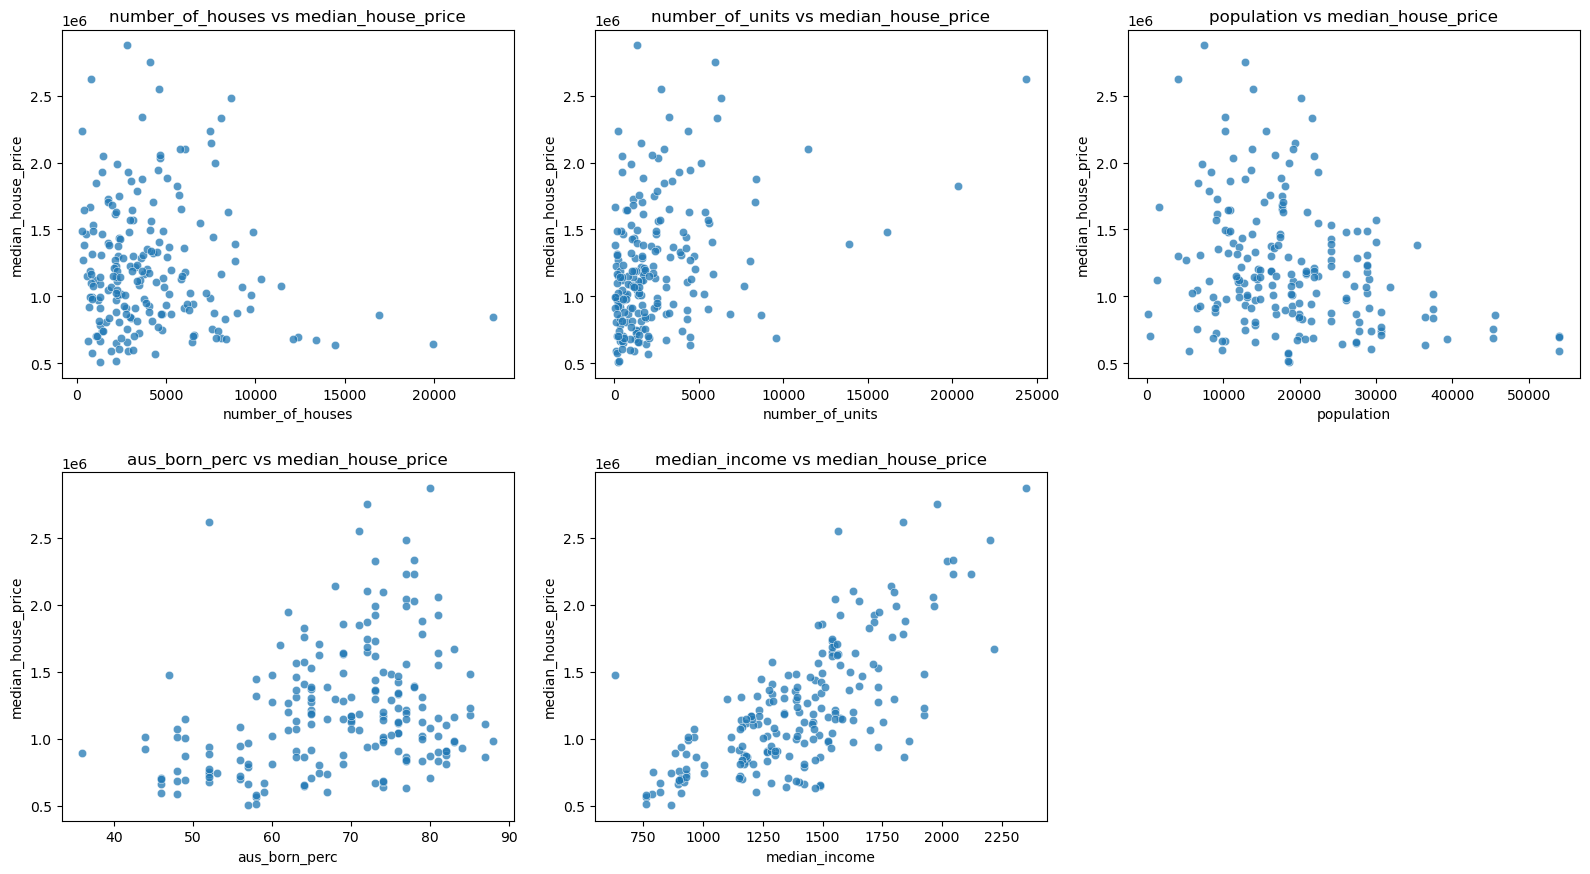

In [13]:

figure_dir = ROOT / "task2_figures"
figure_dir.mkdir(exist_ok=True)
scatter_figure_path = figure_dir / "task2_raw_feature_target_scatter.png"

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for axis_index, feature in enumerate(feature_columns):
    axes[axis_index].scatter(
        analysis_data[feature],
        analysis_data[target_column],
        alpha=0.75,
        edgecolor="white",
        linewidth=0.4,
    )
    axes[axis_index].set_title(f"{feature} vs {target_column}")
    axes[axis_index].set_xlabel(feature)
    axes[axis_index].set_ylabel(target_column)

axes[-1].axis("off")
plt.tight_layout()
fig.savefig(scatter_figure_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)

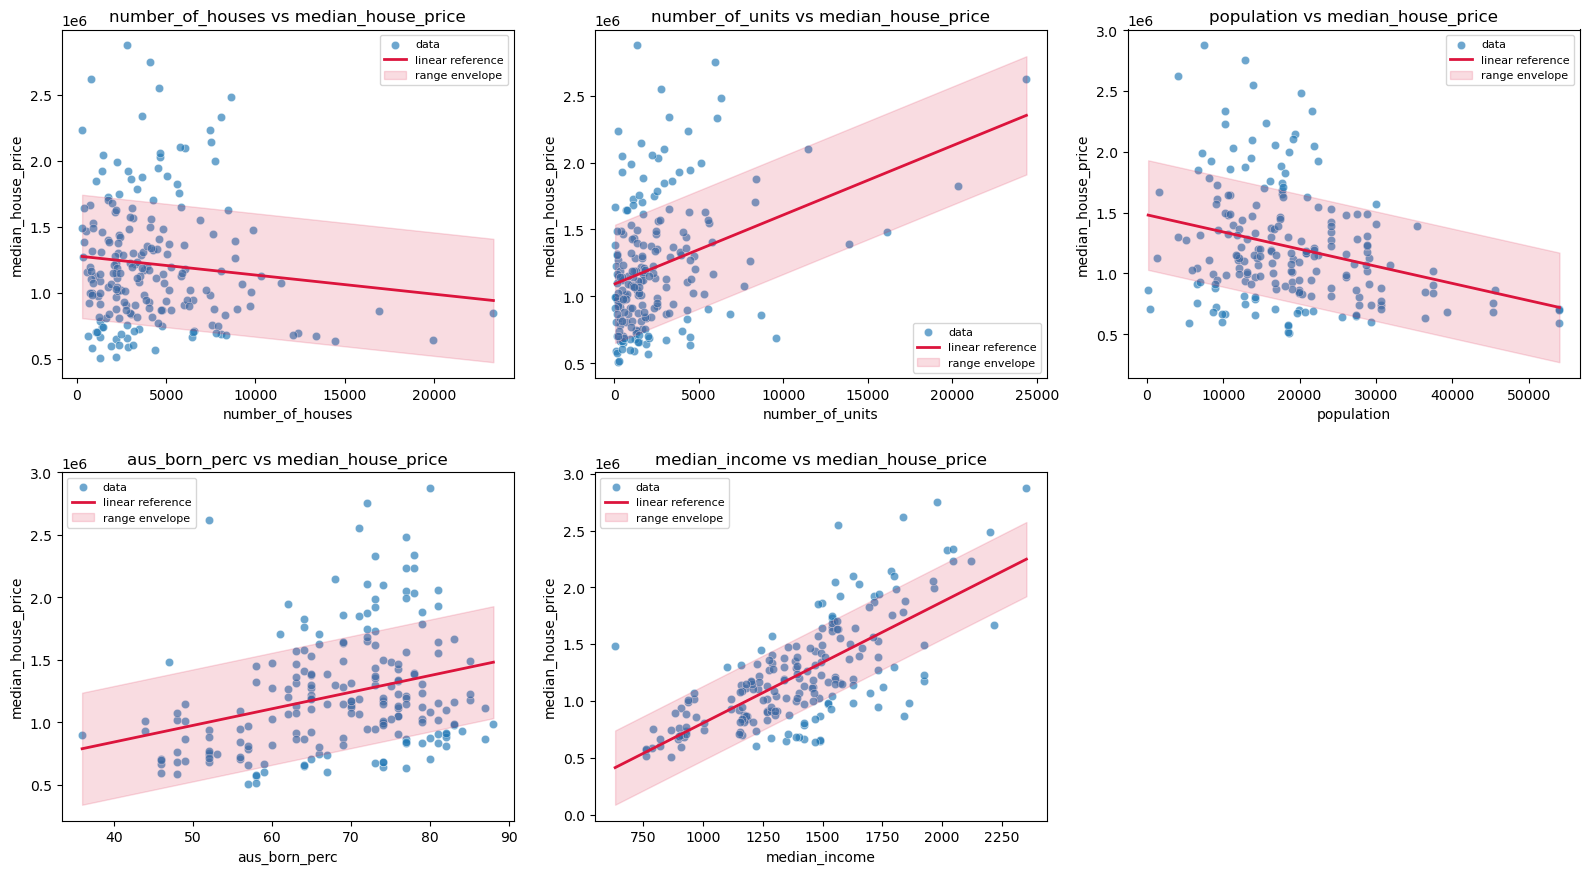

In [14]:
scatter_reference_path = figure_dir / "task2_raw_feature_target_scatter_with_reference.png"

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for axis_index, feature in enumerate(feature_columns):
    x = analysis_data[feature].to_numpy(dtype=float)
    y = analysis_data[target_column].to_numpy(dtype=float)

    axes[axis_index].scatter(
        x,
        y,
        alpha=0.65,
        edgecolor="white",
        linewidth=0.4,
        label="data",
    )

    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = slope * x_line + intercept

    residuals = y - (slope * x + intercept)
    envelope = residuals.std()

    axes[axis_index].plot(x_line, y_line, color="crimson", linewidth=2, label="linear reference")
    axes[axis_index].fill_between(
        x_line,
        y_line - envelope,
        y_line + envelope,
        color="crimson",
        alpha=0.15,
        label="range envelope",
    )

    axes[axis_index].set_title(f"{feature} vs {target_column}")
    axes[axis_index].set_xlabel(feature)
    axes[axis_index].set_ylabel(target_column)
    axes[axis_index].legend(loc="best", fontsize=8)

axes[-1].axis("off")
plt.tight_layout()
fig.savefig(scatter_reference_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)

看完 baseline correlation 和 scatter plots 后，我们重点问：

1. 哪些 feature 和 `median_house_price` 的线性关系最强？
2. 哪些 feature 的 Pearson 和 Spearman 差别明显？如果 Spearman 更强，可能说明关系是单调的，但不是很线性。
3. 哪些 scatter plot 呈现弯曲、扇形、长尾压缩等形状？这些变量后面可能适合 log 或 power transformation。
4. 如果一个 feature 原始 correlation 很弱，我们是否应该完全放弃它？还是先看 transformation 是否改善关系？

下一步建议构造候选变换版本：raw、log1p、sqrt、Box-Cox、Yeo-Johnson，并比较它们和 target 的 Pearson correlation。

# 比较候选 transformation

现在我们有了两个 baseline：

- 原始变量的分布形状。
- 原始 feature 和 `median_house_price` 的线性关系。

下一步开始比较不同 transformation。这里先只回答一个问题：**每个变量经过不同 transformation 后，偏态有没有改善，以及和 target 的 Pearson correlation 有没有增强。**

我们比较这些候选方法：

- `raw`：不变换。
- `log1p`：适合正值、右偏、包含 0 风险较低的变量。
- `sqrt`：比 log 温和，适合计数型右偏变量。
- `boxcox`：要求所有值必须大于 0。
- `yeo_johnson`：可以处理非正数，但这里主要作为 power transformation 的通用版本。

注意：这里还没有做 standardisation/min-max，因为它们只改变 scale，不改变 correlation 和 distribution shape。我们会在下一步单独讨论 scaling。

In [15]:
from scipy import stats
from sklearn.preprocessing import PowerTransformer

transformation_results = []
transformed_candidates = {}

def transform_series(series, method):
    values = series.astype(float).to_numpy()
    if method == "raw":
        return values
    if method == "log1p":
        return np.log1p(values)
    if method == "sqrt":
        return np.sqrt(values)
    if method == "boxcox":
        transformed_values, _ = stats.boxcox(values)
        return transformed_values
    if method == "yeo_johnson":
        transformer = PowerTransformer(method="yeo-johnson", standardize=False)
        return transformer.fit_transform(values.reshape(-1, 1)).ravel()
    raise ValueError(f"Unknown method: {method}")

methods = ["raw", "log1p", "sqrt", "boxcox", "yeo_johnson"]
comparison_columns = feature_columns + [target_column]

for column in comparison_columns:
    transformed_candidates[column] = {}
    for method in methods:
        transformed_values = transform_series(analysis_data[column], method)
        transformed_candidates[column][method] = transformed_values
        correlation_with_raw_target = np.corrcoef(
            transformed_values,
            analysis_data[target_column].to_numpy(),
        )[0, 1]
        transformation_results.append({
            "column": column,
            "method": method,
            "skewness": pd.Series(transformed_values).skew(),
            "pearson_with_raw_target": correlation_with_raw_target,
            "absolute_pearson": abs(correlation_with_raw_target),
        })

transformation_comparison = pd.DataFrame(transformation_results)

print("Transformation comparison sorted by column and absolute Pearson correlation:")
display(
    transformation_comparison
    .sort_values(["column", "absolute_pearson"], ascending=[True, False])
    .reset_index(drop=True)
)

best_by_column = (
    transformation_comparison
    .sort_values(["column", "absolute_pearson"], ascending=[True, False])
    .groupby("column", as_index=False)
    .first()
)

print()
print("Best method per column by absolute Pearson correlation with raw target:")
display(best_by_column)

Transformation comparison sorted by column and absolute Pearson correlation:


,column,method,skewness,pearson_with_raw_target,absolute_pearson
0,aus_born_perc,log1p,-0.9173,0.3154,0.3154
1,aus_born_perc,sqrt,-0.7382,0.3103,0.3103
2,aus_born_perc,raw,-0.5679,0.3039,0.3039
3,aus_born_perc,boxcox,-0.1286,0.2789,0.2789
4,aus_born_perc,yeo_johnson,-0.1277,0.2788,0.2788
5,median_house_price,raw,1.0333,1.0000,1.0000
6,median_house_price,sqrt,0.5927,0.9937,0.9937
7,median_house_price,log1p,0.1729,0.9750,0.9750
8,median_house_price,yeo_johnson,0.0135,0.9645,0.9645
9,median_house_price,boxcox,0.0135,0.9645,0.9645



Best method per column by absolute Pearson correlation with raw target:


,column,method,skewness,pearson_with_raw_target,absolute_pearson
0,aus_born_perc,log1p,-0.9173,0.3154,0.3154
1,median_house_price,raw,1.0333,1.0000,1.0000
2,median_income,raw,0.1725,0.7194,0.7194
3,number_of_houses,raw,2.1562,-0.1045,0.1045
4,number_of_units,sqrt,1.3239,0.3552,0.3552
5,population,raw,1.0859,-0.2872,0.2872


# 讨论问题

这个 comparison table 不能机械地理解成“谁 correlation 最大就选谁”。我们要一起判断：

1. 对 feature 来说，某个 transformation 是否同时改善 skewness 和 linear correlation？
2. 对 `median_house_price` 这个 target 来说，和 raw target 的 correlation 不适合作为选择标准；target transformation 要看它自己的 skewness，以及后面和 transformed features 的关系。
3. `median_income` 原本就接近对称，如果 transformation 只带来很小提升，是否值得改变它的解释性？
4. `aus_born_perc` 是百分比变量，是否应该优先考虑保持 raw 或只做 scaling？

下一步我们应该更公平地比较：如果 target 也 transformation，那么每个 transformed feature 应该和 transformed target 重新计算 correlation。

# 同时比较 feature 和 target transformation
我们把每个 transformed feature 都拿去和 **raw target** 比较。

但如果我们决定对 `median_house_price` 也做 transformation，那么更公平的比较应该是：

- transformed feature vs raw target
- transformed feature vs log target
- transformed feature vs sqrt target
- transformed feature vs Box-Cox / Yeo-Johnson target

这一步的目的不是自动选答案，而是帮助我们看：target 变换后，哪些 feature 的线性关系更稳定、更强。


In [16]:
target_methods = ["raw", "log1p", "sqrt", "boxcox", "yeo_johnson"]
feature_methods = ["raw", "log1p", "sqrt", "boxcox", "yeo_johnson"]

pairwise_rows = []
for feature in feature_columns:
    for feature_method in feature_methods:
        feature_values = transformed_candidates[feature][feature_method]
        for target_method in target_methods:
            target_values = transformed_candidates[target_column][target_method]
            pearson_corr = np.corrcoef(feature_values, target_values)[0, 1]
            pairwise_rows.append({
                "feature": feature,
                "feature_method": feature_method,
                "target_method": target_method,
                "pearson_correlation": pearson_corr,
                "absolute_pearson": abs(pearson_corr),
                "feature_skewness": pd.Series(feature_values).skew(),
                "target_skewness": pd.Series(target_values).skew(),
            })

pairwise_comparison = pd.DataFrame(pairwise_rows)

best_pairwise_by_feature = (
    pairwise_comparison
    .sort_values(["feature", "absolute_pearson"], ascending=[True, False])
    .groupby("feature", as_index=False)
    .first()
)

print("Best feature-target transformation pairs by absolute Pearson correlation:")
display(best_pairwise_by_feature)

print()
print("Top 5 transformation pairs for each feature:")
for feature in feature_columns:
    print()
    print(feature)
    display(
        pairwise_comparison[pairwise_comparison["feature"] == feature]
        .sort_values("absolute_pearson", ascending=False)
        .head(5)
        .reset_index(drop=True)
    )

Best feature-target transformation pairs by absolute Pearson correlation:


,feature,feature_method,target_method,pearson_correlation,absolute_pearson,feature_skewness,target_skewness
0,aus_born_perc,log1p,boxcox,0.3659,0.3659,-0.9173,0.0135
1,median_income,raw,sqrt,0.7235,0.7235,0.1725,0.5927
2,number_of_houses,raw,yeo_johnson,-0.1347,0.1347,2.1562,0.0135
3,number_of_units,sqrt,raw,0.3552,0.3552,1.3239,1.0333
4,population,raw,yeo_johnson,-0.2990,0.2990,1.0859,0.0135



Top 5 transformation pairs for each feature:

number_of_houses


,feature,feature_method,target_method,pearson_correlation,absolute_pearson,feature_skewness,target_skewness
0,number_of_houses,raw,yeo_johnson,-0.1347,0.1347,2.1562,0.0135
1,number_of_houses,raw,boxcox,-0.1347,0.1347,2.1562,0.0135
2,number_of_houses,raw,log1p,-0.1310,0.1310,2.1562,0.1729
3,number_of_houses,raw,sqrt,-0.1191,0.1191,2.1562,0.5927
4,number_of_houses,raw,raw,-0.1045,0.1045,2.1562,1.0333



number_of_units


...

,feature,feature_method,target_method,pearson_correlation,absolute_pearson,feature_skewness,target_skewness
0,population,raw,yeo_johnson,-0.2990,0.2990,1.0859,0.0135
1,population,raw,boxcox,-0.2990,0.2990,1.0859,0.0135
2,population,raw,log1p,-0.2985,0.2985,1.0859,0.1729
3,population,raw,sqrt,-0.2947,0.2947,1.0859,0.5927
4,population,raw,raw,-0.2872,0.2872,1.0859,1.0333



aus_born_perc


,feature,feature_method,target_method,pearson_correlation,absolute_pearson,feature_skewness,target_skewness
0,aus_born_perc,log1p,boxcox,0.3659,0.3659,-0.9173,0.0135
1,aus_born_perc,log1p,yeo_johnson,0.3659,0.3659,-0.9173,0.0135
2,aus_born_perc,sqrt,boxcox,0.3609,0.3609,-0.7382,0.0135
3,aus_born_perc,sqrt,yeo_johnson,0.3609,0.3609,-0.7382,0.0135
4,aus_born_perc,log1p,log1p,0.3591,0.3591,-0.9173,0.1729



median_income


,feature,feature_method,target_method,pearson_correlation,absolute_pearson,feature_skewness,target_skewness
0,median_income,raw,sqrt,0.7235,0.7235,0.1725,0.5927
1,median_income,raw,log1p,0.7198,0.7198,0.1725,0.1729
2,median_income,raw,raw,0.7194,0.7194,0.1725,1.0333
3,median_income,yeo_johnson,sqrt,0.7183,0.7183,-0.0084,0.5927
4,median_income,boxcox,sqrt,0.7183,0.7183,-0.0084,0.5927


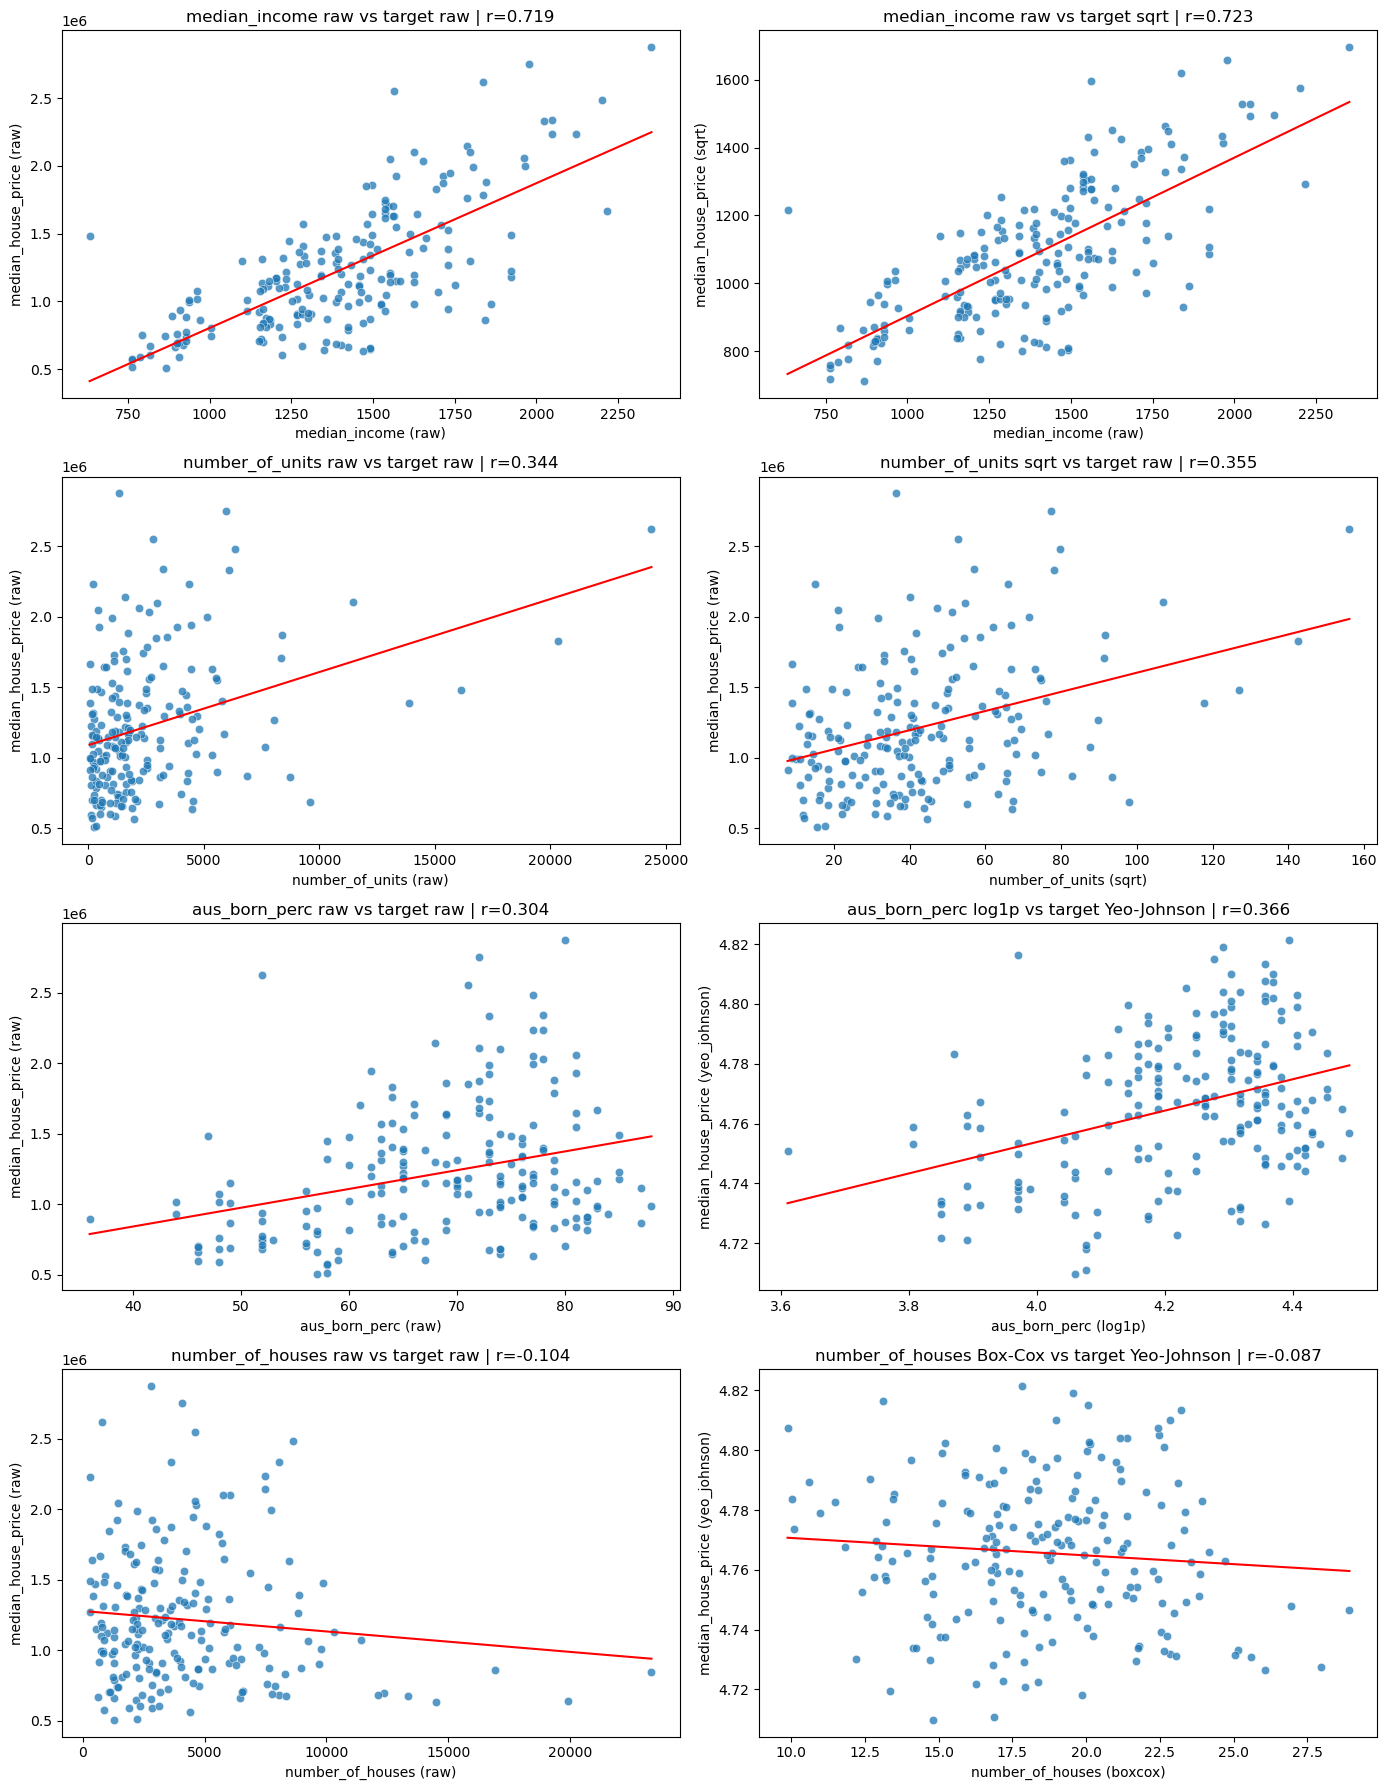

Representative scatter figure saved to:
/Users/songhaifan/Documents/GitHub/teaching-materials/courses/lincoin/materials/fit5196/ass2_2026/task2_figures/task2_representative_transformed_scatter.png

Correlations shown in the representative plots:


,feature,feature_method,target_method,pearson_correlation
0,median_income,raw,raw,0.7194
1,median_income,raw,sqrt,0.7235
2,number_of_units,raw,raw,0.3439
3,number_of_units,sqrt,raw,0.3552
4,aus_born_perc,raw,raw,0.3039
5,aus_born_perc,log1p,yeo_johnson,0.3659
6,number_of_houses,raw,raw,-0.1045
7,number_of_houses,boxcox,yeo_johnson,-0.0870


In [17]:
representative_pairs = [
    {
        "feature": "median_income",
        "feature_method": "raw",
        "target_method": "raw",
        "title": "median_income raw vs target raw",
    },
    {
        "feature": "median_income",
        "feature_method": "raw",
        "target_method": "sqrt",
        "title": "median_income raw vs target sqrt",
    },
    {
        "feature": "number_of_units",
        "feature_method": "raw",
        "target_method": "raw",
        "title": "number_of_units raw vs target raw",
    },
    {
        "feature": "number_of_units",
        "feature_method": "sqrt",
        "target_method": "raw",
        "title": "number_of_units sqrt vs target raw",
    },
    {
        "feature": "aus_born_perc",
        "feature_method": "raw",
        "target_method": "raw",
        "title": "aus_born_perc raw vs target raw",
    },
    {
        "feature": "aus_born_perc",
        "feature_method": "log1p",
        "target_method": "yeo_johnson",
        "title": "aus_born_perc log1p vs target Yeo-Johnson",
    },
    {
        "feature": "number_of_houses",
        "feature_method": "raw",
        "target_method": "raw",
        "title": "number_of_houses raw vs target raw",
    },
    {
        "feature": "number_of_houses",
        "feature_method": "boxcox",
        "target_method": "yeo_johnson",
        "title": "number_of_houses Box-Cox vs target Yeo-Johnson",
    },
]

figure_dir = ROOT / "task2_figures"
figure_dir.mkdir(exist_ok=True)
representative_figure_path = figure_dir / "task2_representative_transformed_scatter.png"

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

plot_rows = []
for axis, pair in zip(axes, representative_pairs):
    feature_values = transformed_candidates[pair["feature"]][pair["feature_method"]]
    target_values = transformed_candidates[target_column][pair["target_method"]]
    pearson_corr = np.corrcoef(feature_values, target_values)[0, 1]

    axis.scatter(feature_values, target_values, alpha=0.75, edgecolor="white", linewidth=0.4)
    slope, intercept = np.polyfit(feature_values, target_values, 1)
    x_line = np.linspace(np.min(feature_values), np.max(feature_values), 100)
    axis.plot(x_line, slope * x_line + intercept, color="red", linewidth=1.5)
    axis.set_title(f"{pair['title']} | r={pearson_corr:.3f}")
    axis.set_xlabel(f"{pair['feature']} ({pair['feature_method']})")
    axis.set_ylabel(f"{target_column} ({pair['target_method']})")

    plot_rows.append({
        "feature": pair["feature"],
        "feature_method": pair["feature_method"],
        "target_method": pair["target_method"],
        "pearson_correlation": pearson_corr,
    })

plt.tight_layout()
fig.savefig(representative_figure_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Representative scatter figure saved to:")
print(representative_figure_path)

print()
print("Correlations shown in the representative plots:")
display(pd.DataFrame(plot_rows))

# 比较 scaling 方法

现在讨论 scaling。这里要先区分两个概念：

- **Transformation**：改变变量形状，例如 log、sqrt、Box-Cox、Yeo-Johnson，可能改变 skewness 和线性关系。
- **Scaling**：改变变量单位，例如 StandardScaler、MinMaxScaler、RobustScaler，通常不改变变量排序，也不会改变 Pearson correlation。

Assignment guide 要求 features 在 comparable scale 上。因此，即使某些变量不需要 log/sqrt，也可能仍然需要 scaling。

我们比较：

- `standard`：均值 0，标准差 1。适合相对接近正态、离群影响不强的变量。
- `minmax`：压到 0-1。直观，但对极端值敏感。
- `robust`：用 median 和 IQR，面对长尾和 potential outliers 更稳定。

In [18]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

scaling_features = feature_columns.copy()
scalers = {
    "raw": None,
    "standard": StandardScaler(),
    "minmax": MinMaxScaler(),
    "robust": RobustScaler(),
}

scaled_feature_frames = {}
for scaler_name, scaler in scalers.items():
    if scaler is None:
        scaled_values = analysis_data[scaling_features].copy()
    else:
        scaled_values = pd.DataFrame(
            scaler.fit_transform(analysis_data[scaling_features]),
            columns=scaling_features,
            index=analysis_data.index,
        )
    scaled_feature_frames[scaler_name] = scaled_values

scaling_summary_rows = []
for scaler_name, scaled_frame in scaled_feature_frames.items():
    for column in scaling_features:
        scaling_summary_rows.append({
            "scaler": scaler_name,
            "feature": column,
            "mean": scaled_frame[column].mean(),
            "std": scaled_frame[column].std(ddof=0),
            "min": scaled_frame[column].min(),
            "median": scaled_frame[column].median(),
            "max": scaled_frame[column].max(),
            "iqr": scaled_frame[column].quantile(0.75) - scaled_frame[column].quantile(0.25),
            "pearson_with_target": scaled_frame[column].corr(analysis_data[target_column]),
        })

scaling_summary = pd.DataFrame(scaling_summary_rows)

print("Scaling summary:")
display(scaling_summary)

print()
print("Pearson correlations after scaling should match raw correlations, up to sign-preserving numerical precision:")
display(
    scaling_summary
    .pivot(index="feature", columns="scaler", values="pearson_with_target")
    .loc[scaling_features]
)

Scaling summary:


,scaler,feature,mean,std,min,median,max,iqr,pearson_with_target
0,raw,number_of_houses,"4,155.7673","3,392.4366",283.0000,"3,256.5000","23,338.0000","3,545.0000",-0.1045
1,raw,number_of_units,"2,480.4109","3,124.9209",60.0000,"1,603.0000","24,380.0000","2,468.5000",0.3439
2,raw,population,"18,659.3119","9,580.3850",170.0000,"17,583.0000","54,005.0000","11,982.0000",-0.2872
3,raw,aus_born_perc,68.3663,10.7346,36.0000,70.0000,88.0000,15.0000,0.3039
4,raw,median_income,"1,387.9356",317.0536,633.0000,"1,393.0000","2,352.0000",377.7500,0.7194
5,standard,number_of_houses,-0.0000,1.0000,-1.1416,-0.2651,5.6544,1.0450,-0.1045
6,standard,number_of_units,-0.0000,1.0000,-0.7746,-0.2808,7.0080,0.7899,0.3439
7,standard,population,0.0000,1.0000,-1.9299,-0.1123,3.6894,1.2507,-0.2872
8,standard,aus_born_perc,0.0000,1.0000,-3.0151,0.1522,1.8290,1.3973,0.3039
9,standard,median_income,-0.0000,1.0000,-2.3811,0.0160,3.0407,1.1914,0.7194



Pearson correlations after scaling should match raw correlations, up to sign-preserving numerical precision:


scaler,minmax,raw,robust,standard
feature,,,,
number_of_houses,-0.1045,-0.1045,-0.1045,-0.1045
number_of_units,0.3439,0.3439,0.3439,0.3439
population,-0.2872,-0.2872,-0.2872,-0.2872
aus_born_perc,0.3039,0.3039,0.3039,0.3039
median_income,0.7194,0.7194,0.7194,0.7194


看完 scaling summary 后，我们要讨论：

1. StandardScaler 是否成功让每个 feature 变成 mean 0、std 1？
2. MinMaxScaler 是否把所有 feature 压到 0-1？它为什么可能受极端值影响？
3. RobustScaler 的 median 是否接近 0，IQR 是否接近 1？这对长尾变量有什么好处？
4. 为什么 scaling 后 Pearson correlation 没变？这说明 scaling 解决的不是 linearity，而是 comparable scale。

下一步建议画 scaled distributions，尤其比较 raw / standard / minmax / robust 在长尾变量上的效果。


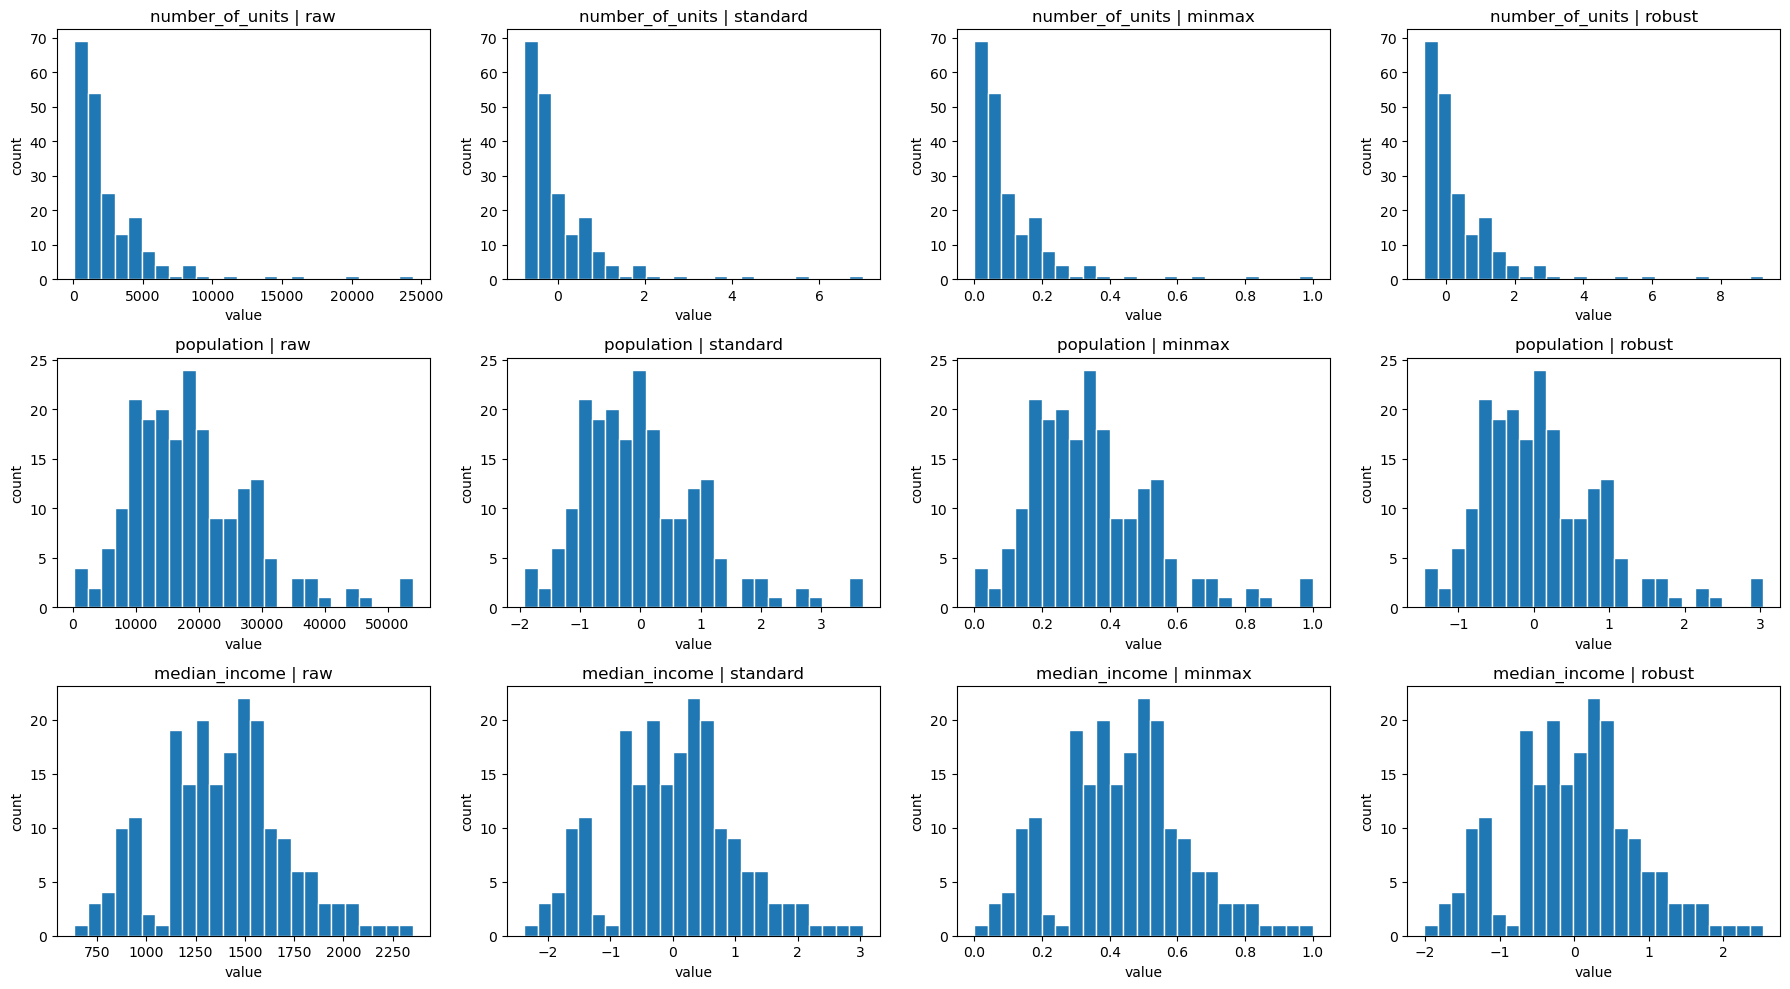

Scaling distribution comparison saved to:
/Users/songhaifan/Documents/GitHub/teaching-materials/courses/lincoin/materials/fit5196/ass2_2026/task2_figures/task2_scaling_distribution_comparison.png

Selected quantiles after scaling:


,feature,scaler,q00_min,q25,q50_median,q75,q95,q100_max
0,number_of_units,raw,60.0000,620.5000,"1,603.0000","3,089.0000","7,631.6000","24,380.0000"
1,number_of_units,standard,-0.7746,-0.5952,-0.2808,0.1948,1.6484,7.0080
2,number_of_units,minmax,0.0000,0.0230,0.0634,0.1245,0.3113,1.0000
3,number_of_units,robust,-0.6251,-0.3980,0.0000,0.6020,2.4422,9.2271
4,population,raw,170.0000,"12,063.0000","17,583.0000","24,045.0000","36,356.0000","54,005.0000"
5,population,standard,-1.9299,-0.6885,-0.1123,0.5622,1.8472,3.6894
6,population,minmax,0.0000,0.2209,0.3235,0.4435,0.6722,1.0000
7,population,robust,-1.4533,-0.4607,0.0000,0.5393,1.5668,3.0397
8,median_income,raw,633.0000,"1,182.2500","1,393.0000","1,560.0000","1,923.0000","2,352.0000"
9,median_income,standard,-2.3811,-0.6487,0.0160,0.5427,1.6876,3.0407


In [19]:
scaling_plot_features = ["number_of_units", "population", "median_income"]
scaling_plot_order = ["raw", "standard", "minmax", "robust"]
scaling_distribution_path = figure_dir / "task2_scaling_distribution_comparison.png"

fig, axes = plt.subplots(len(scaling_plot_features), len(scaling_plot_order), figsize=(18, 10))

for row_index, feature in enumerate(scaling_plot_features):
    for column_index, scaler_name in enumerate(scaling_plot_order):
        values = scaled_feature_frames[scaler_name][feature]
        axes[row_index, column_index].hist(values, bins=25, edgecolor="white")
        axes[row_index, column_index].set_title(f"{feature} | {scaler_name}")
        axes[row_index, column_index].set_xlabel("value")
        axes[row_index, column_index].set_ylabel("count")

plt.tight_layout()
fig.savefig(scaling_distribution_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Scaling distribution comparison saved to:")
print(scaling_distribution_path)

scaled_quantile_rows = []
for feature in scaling_plot_features:
    for scaler_name in scaling_plot_order:
        values = scaled_feature_frames[scaler_name][feature]
        scaled_quantile_rows.append({
            "feature": feature,
            "scaler": scaler_name,
            "q00_min": values.quantile(0.00),
            "q25": values.quantile(0.25),
            "q50_median": values.quantile(0.50),
            "q75": values.quantile(0.75),
            "q95": values.quantile(0.95),
            "q100_max": values.quantile(1.00),
        })

print()
print("Selected quantiles after scaling:")
display(pd.DataFrame(scaled_quantile_rows))


最终首选方案：

| Column | Recommended transformation | Recommended scaling | Why |
|---|---|---|---|
| `number_of_houses` | raw | RobustScaler | 关系弱，变换无明显收益；但右尾明显，需要 robust scaling。 |
| `number_of_units` | sqrt | RobustScaler | 右偏最明显，sqrt 能缓解左侧挤压并略微提升线性关系。 |
| `population` | raw | RobustScaler | feature transformation 收益小；保留解释性，用 robust scaling 处理右尾。 |
| `aus_born_perc` | raw | StandardScaler | 百分比变量，log 解释性差且会加重左偏；standard scaling 足够。 |
| `median_income` | raw | StandardScaler | 分布接近对称，且原始线性关系最强。 |
| `median_house_price` | sqrt | no feature scaling required | target 右偏，sqrt 是比 Box-Cox/Yeo-Johnson 更可解释的温和变换。 |

注意：这里的 preview 不是要作为 Task 2 的提交 CSV。Task 2 主要提交 notebook 中的比较、解释和推荐。


Task 2 的核心不是训练最终模型，而是研究 `suburb_info.xlsx` 中的变量是否需要 reshaping，目的是为后续线性回归准备更合适的数据。根据 assignment guide，我们重点关注两个标准：

1. features 是否在 comparable scale 上；
2. features 和 target `median_house_price` 是否尽可能接近线性关系。

因此，我们的分析顺序是：

`读取数据 -> 类型转换 -> 数值 summary -> 分布检查 -> 原始线性关系 baseline -> transformation 比较 -> scaling 比较 -> final recommendation`

### 2. 数据格式处理

原始数据中 `aus_born_perc`、`median_income`、`median_house_price` 是字符串格式，分别包含 `%`、`$` 和逗号。我们先把它们转换成数值。这个步骤不是 transformation，而是让数据恢复成可分析的 numeric format。

转换后没有 missing values，6 个 Task 2 变量都可以进行数值分析。

### 3. 原始数据发现

原始变量的 scale 差异很大：

- `median_house_price` 是百万量级；
- `population`、`number_of_houses`、`number_of_units` 是几万量级；
- `aus_born_perc` 只有 36 到 88；
- `median_income` 是千元量级。

这说明 scaling 是必要的，否则不同量纲的 feature 在后续线性回归中不容易比较。

分布方面：

- `number_of_units` 和 `number_of_houses` 右偏最明显；
- `population` 和 `median_house_price` 也有右尾；
- `median_income` 接近对称；
- `aus_born_perc` 是百分比变量，轻微左偏。

### 4. 原始线性关系 baseline

原始 feature 与 `median_house_price` 的 Pearson correlation 显示：

- `median_income` 最强，约为 0.719；
- `number_of_units` 和 `aus_born_perc` 是中等偏弱正相关；
- `population` 是中等偏弱负相关；
- `number_of_houses` 很弱。

Scatter plots 也支持这个判断：`median_income` 的正趋势最明显，而 `number_of_houses` 即使经过变换也没有形成清晰线性关系。

### 5. Transformation 结论

我们比较了 `raw`、`log1p`、`sqrt`、`Box-Cox` 和 `Yeo-Johnson`。最终没有机械选择最高 correlation，而是结合 skewness、图像和变量含义。

最终推荐：

| Column | Recommended transformation | Reason |
|---|---|---|
| `number_of_houses` | raw | 关系本来很弱，变换没有实质改善；保留解释性。 |
| `number_of_units` | sqrt | 右偏最明显，sqrt 缓解长尾压缩，并带来小幅线性关系改善。 |
| `population` | raw | feature transformation 没有改善关系；保留原始含义。 |
| `aus_born_perc` | raw | 百分比变量，log 虽略提 correlation，但解释性差且加重左偏。 |
| `median_income` | raw | 原始分布接近对称，也是最强 predictor，变换收益很小。 |
| `median_house_price` | sqrt | target 右偏，sqrt 是温和且较可解释的 target transformation。 |

### 6. Scaling 结论

Scaling 后 correlation 没有变化，这符合理论预期：scaling 解决的是 comparable scale，不是 skewness 或 linearity。

最终推荐：

| Feature | Recommended scaler | Reason |
|---|---|---|
| `number_of_houses` | RobustScaler | 右尾明显，高值 suburb 会影响 mean/std。 |
| `number_of_units` | RobustScaler | 右偏和极端高值最明显，MinMax 会压缩大多数样本。 |
| `population` | RobustScaler | 有右尾和高人口 suburb，median/IQR 更稳健。 |
| `aus_born_perc` | StandardScaler | 分布较集中，百分比变量没有严重右尾。 |
| `median_income` | StandardScaler | 分布接近对称，StandardScaler 足够自然。 |

### 7. 被尝试但没有作为首选的方法

- `MinMaxScaler`：可以把数据压到 0-1，但对 `number_of_units` 这类长尾变量非常敏感，导致大多数 suburb 被挤在接近 0 的范围。
- `log1p`：对一些右偏变量有帮助，但在本数据中对 `population` 和 `number_of_houses` 的线性关系改善不明显；对 `aus_born_perc` 还会降低解释性。
- `Box-Cox` / `Yeo-Johnson`：能让某些变量 skewness 更接近 0，但不一定提升和 target 的线性关系，而且解释成本更高。
- 对所有列一刀切使用同一个 scaler：不推荐，因为不同变量的分布形状不同。

### 8. 最终推荐方案

如果要为后续线性回归准备数据，本 notebook 的首选方案是：

- `sqrt(number_of_units)` + `RobustScaler`
- `number_of_houses` raw + `RobustScaler`
- `population` raw + `RobustScaler`
- `aus_born_perc` raw + `StandardScaler`
- `median_income` raw + `StandardScaler`
- target 使用 `sqrt(median_house_price)`

# Optional OLS diagnostics：只作为 reshaping 的辅助证据

这一节是可选诊断，不是 Task 2 的主任务。

为什么可以做？

- Assignment guide 关心的是 transformation 是否让数据更适合后续 linear regression。
- 一个简单 OLS 可以作为 sanity check：看 reshaped features 是否让整体线性拟合更稳定。
- QQ plot 可以帮助观察 residuals 是否更接近正态。

但要注意：

- 这不是最终预测模型训练。
- 不能只为了 adjusted R² 牺牲变量解释性。
- 如果 target 从 raw price 变成 sqrt price，adjusted R² 不应该和 raw target 模型直接粗暴比较，因为响应变量的尺度已经不同。

所以我们比较三种设计：

1. `raw_features_raw_target`：原始 numeric features + 原始房价。
2. `recommended_features_raw_target`：推荐处理后的 features + 原始房价。这个可以和 1 做同 target 的 adjusted R² 比较。
3. `recommended_features_sqrt_target`：推荐处理后的 features + sqrt 房价。这个主要看 residual shape 和 QQ plot，作为 target transformation 的辅助证据。

In [20]:
import statsmodels.api as sm
from scipy import stats as scipy_stats

ols_designs = []

raw_X = analysis_data[feature_columns].copy()
raw_y = analysis_data[target_column].copy()
recommended_X = prepared_data[final_feature_columns].copy()
sqrt_y = prepared_data[final_target_column].copy()

model_specs = [
    {
        "design": "raw_features_raw_target",
        "X": raw_X,
        "y": raw_y,
        "target_scale": "raw median_house_price",
        "comparable_adjusted_r2_group": "raw_target",
    },
    {
        "design": "recommended_features_raw_target",
        "X": recommended_X,
        "y": raw_y,
        "target_scale": "raw median_house_price",
        "comparable_adjusted_r2_group": "raw_target",
    },
    {
        "design": "recommended_features_sqrt_target",
        "X": recommended_X,
        "y": sqrt_y,
        "target_scale": "sqrt median_house_price",
        "comparable_adjusted_r2_group": "sqrt_target_only",
    },
]

fitted_models = {}
diagnostic_rows = []
for spec in model_specs:
    X_with_constant = sm.add_constant(spec["X"])
    model = sm.OLS(spec["y"], X_with_constant).fit()
    fitted_models[spec["design"]] = model
    residuals = pd.Series(model.resid, index=spec["X"].index)
    shapiro_statistic, shapiro_p_value = scipy_stats.shapiro(residuals)
    diagnostic_rows.append({
        "design": spec["design"],
        "target_scale": spec["target_scale"],
        "adjusted_r_squared": model.rsquared_adj,
        "aic": model.aic,
        "residual_mean": residuals.mean(),
        "residual_std": residuals.std(),
        "residual_skewness": residuals.skew(),
        "shapiro_p_value": shapiro_p_value,
        "r2_comparison_note": spec["comparable_adjusted_r2_group"],
    })

ols_diagnostics = pd.DataFrame(diagnostic_rows)

print("OLS diagnostic summary:")
display(ols_diagnostics)

ols_figure_path = figure_dir / "task2_optional_ols_diagnostics.png"
fig, axes = plt.subplots(len(model_specs), 2, figsize=(14, 13))

for row_index, spec in enumerate(model_specs):
    model = fitted_models[spec["design"]]
    residuals = pd.Series(model.resid)

    axes[row_index, 0].scatter(model.fittedvalues, residuals, alpha=0.75, edgecolor="white", linewidth=0.4)
    axes[row_index, 0].axhline(0, color="red", linewidth=1.2)
    axes[row_index, 0].set_title(f"Residuals vs fitted: {spec['design']}")
    axes[row_index, 0].set_xlabel("fitted values")
    axes[row_index, 0].set_ylabel("residuals")

    sm.qqplot(residuals, line="45", ax=axes[row_index, 1], fit=True)
    axes[row_index, 1].set_title(f"QQ plot: {spec['design']}")

plt.tight_layout()
fig.savefig(ols_figure_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)

print()
print("Optional OLS diagnostic figure saved to:")
print(ols_figure_path)

NameError: name 'prepared_data' is not defined